In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


device = (
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26421880/26421880 [00:01<00:00, 18601687.86it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 348424.52it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 6217918.37it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 3341940.41it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



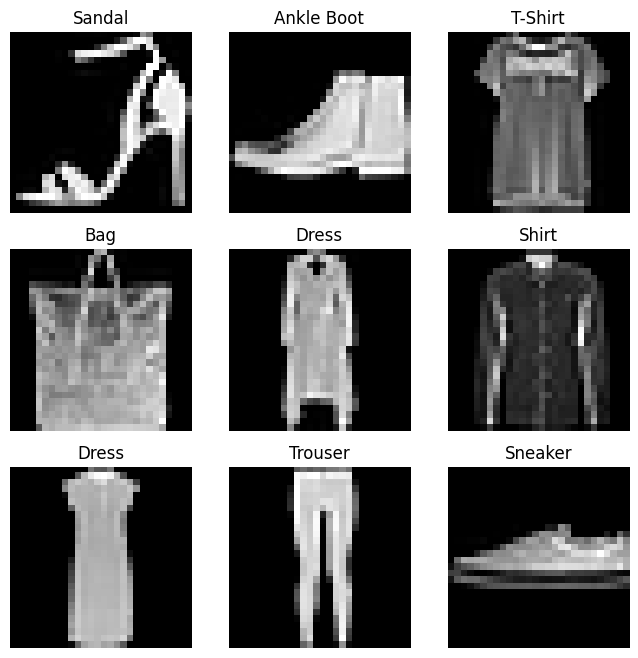

In [3]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [4]:
import os
import numpy as np
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils

class CustomImageDataset(Dataset):
    def __init__(self, data_set, transform=None):
        self.data_set = data_set
        self.transform = transform

    def __len__(self):
        return len(self.data_set)

    def __getitem__(self, idx):
        image, label = self.data_set[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
from torchvision import transforms

data_transform = transforms.Compose([
	transforms.Resize((128, 128)),
	transforms.Normalize([0.485], [0.225])
])

training_dataset = CustomImageDataset(training_data,data_transform)
training_dataloader = DataLoader(training_dataset, batch_size=20, shuffle=True)

test_dataset = CustomImageDataset(training_data,data_transform)
test_dataloader = DataLoader(test_dataset, batch_size=20, shuffle=True)


3000
torch.Size([3, 404, 1069])
torch.Size([404, 1069, 3])


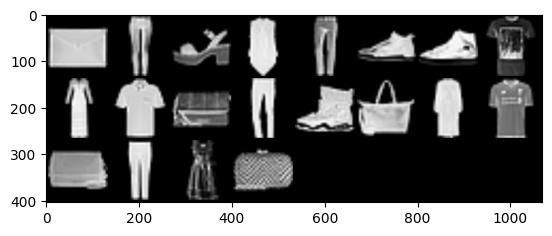

In [7]:
print(training_dataloader.__len__())
for x,y in training_dataloader:
    print(vutils.make_grid(x, padding=5, normalize=True).cpu().shape) # numpy image format
    print(np.transpose(vutils.make_grid(x, padding=5, normalize=True).cpu(),(1,2,0)).shape) # pil image format
    plt.imshow(np.transpose(vutils.make_grid(x, padding=5, normalize=True).cpu(),(1,2,0)))
    break
